# Pytorch

This notebook walks through the Deckard Python API from a PyTorch-centric perspective, including the PyTorch-specific extensions for adversarial robustness, fairness, and model persistence.

## Navigation

1. Environment and imports
2. PyTorch dataset API (`PytorchDataConfig`)
3. PyTorch model API (`PytorchModelConfig`)
4. Adversarial attack API (`PytorchAttackConfig`)
5. End-to-end experiment composition (`TorchExperimentConfig`)
6. ART defense pipeline (`DefensePipelineConfig`)
7. Fairness extension (`FairlearnModelConfig` + `CelebASmileDataset`)
8. Model checkpointing
9. Yellowbrick plotter on a torch experiment
10. Seaborn plotter on tabular results

Each runnable section is introduced by a markdown cell so the notebook reads as a guided tour.

## 1. Environment and Imports

Imports for the PyTorch-centric Deckard API, including optional fairness and defense extensions. An artifact directory is created for model checkpoints and plot outputs.


This notebook covers PyTorch workflows and optional fairness/plotting examples.

Recommended extras:

- `docs`
- `torch`
- `fairlearn`
- `seaborn`
- `yellowbrick`
- `datasets`

Install from repository root:

```bash
pip install -e '.[torch,fairlearn,seaborn,yellowbrick,datasets]'
```

In [1]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[torch,fairlearn,seaborn,yellowbrick,datasets]'

## How To Use This Notebook

This notebook demonstrates a full PyTorch-based deckard workflow from data setup to scoring and diagnostics.

### What You Will Learn

- How model, data, and scorer configs compose into one executable experiment.
- How to interpret probability-based outputs and score dictionaries.
- Where fairness and robustness extensions enter the pipeline.

### Prerequisites

- A working Python environment with deckard dependencies installed.
- Access to local writable artifact paths used by the notebook.
- Optional: DVC configured if you want reproducible stage-based execution.

### Recommended Execution Strategy

1. Run cells top-to-bottom for the first pass.
2. After the baseline run succeeds, change one axis at a time (model, data split, scorer settings).
3. Re-run affected sections and compare score deltas instead of changing multiple knobs simultaneously.

### Debugging Notes

- If probability scoring fails, inspect model output shape/type before scorer execution.
- If fairness metrics fail, verify sensitive-feature attributes are present for the active split.
- If a rerun behaves inconsistently, force a clean stage execution through the notebook DVC stage.

In [2]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from deckard.data import PytorchDataConfig
from deckard.frameworks.pytorch.experiment import TorchExperimentConfig
from deckard.frameworks.pytorch import PytorchModelConfig
from deckard.frameworks.pytorch.attack import PytorchAttackConfig
from deckard.frameworks.pytorch.fairness_data import FairlearnPytorchDataConfig
from deckard.model.defense.base import DefenseConfig, DefensePipelineConfig
from deckard.file import FileConfig
from deckard.score import FairlearnAttackScorerConfig
from deckard.plot import SeabornPlotConfig, SeabornPlotConfigList
from deckard.plugins.fairlearn.model import FairlearnPytorchModelConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")

ARTIFACT_DIR = Path("build/pytorch")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = ARTIFACT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = Path.cwd().resolve().parents[1]

torch_model_file = ARTIFACT_DIR / "pytorch_model.pkl"
torch_data_file = ARTIFACT_DIR / "pytorch_data.pkl"
torch_score_file = ARTIFACT_DIR / "pytorch_scores.csv"

print(f"Artifacts will be written under: {ARTIFACT_DIR}")
print("Using pytorch model target: __main__.MnistCNN")

/Users/c.meyers/.pyenv/versions/3.10.20/envs/deckard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts will be written under: build/pytorch
Using pytorch model target: __main__.MnistCNN


## 2. PyTorch Dataset API

`PytorchDataConfig` loads any `torchvision.datasets`-compatible class (or a custom `torch.utils.data.Dataset`) and produces tensor-based train/test splits. Specify `dataset_name` as a fully qualified class path.

Key differences from `DataConfig`:
- `_X` / `_y` are `torch.Tensor`, not `pd.DataFrame`.
- `target`, `drop`, and `keep` must not be set (torch datasets manage their own label extraction).
- `data_params` passes through to the dataset constructor; `root` is automatically set for `torchvision` datasets from `data_dir`.
- `stratify=True` triggers stratified train/test splitting when possible.

In [3]:
# Load a small subset of MNIST via torchvision.
# DECKARD_TEST_MAX_SAMPLES=256 caps materialization so the cell runs quickly.
import os

os.environ["DECKARD_TEST_MAX_SAMPLES"] = "256"

torch_data = PytorchDataConfig(
    dataset_name="torchvision.datasets.MNIST",
    data_dir=(ARTIFACT_DIR / "raw_data").as_posix(),
    data_params={"download": True, "train": True},
    train_size=200,
    test_size=56,
    random_state=42,
    stratify=True,
    classifier=True,
    scorer=None,  # TODO: Fix torch default data scoring
)

torch_data()

print("Train label counts:", torch.bincount(torch_data.y_train))
print("Load time (s):", round(torch_data.data_load_time, 3))
print("Sample time (s):", round(torch_data.data_sample_time, 3))

  0%|                                               | 0.00/9.91M [00:00<?, ?B/s]

  6%|██▎                                    | 590k/9.91M [00:00<00:01, 5.47MB/s]

 37%|██████████████▏                       | 3.70M/9.91M [00:00<00:00, 14.8MB/s]

 87%|█████████████████████████████████     | 8.62M/9.91M [00:00<00:00, 27.6MB/s]

100%|██████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]

...

 26%|██████████                             | 426k/1.65M [00:00<00:00, 4.01MB/s]

100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 9.82MB/s]

  0%|                                               | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 3.08MB/s]

Train label counts: tensor([24, 27, 20, 23, 19, 13, 19, 20, 15, 20])
Load time (s): 2.042
Sample time (s): 0.001


## 3. PyTorch Model API

`PytorchModelConfig` wraps any `torch.nn.Module` through ART's `PyTorchClassifier` / `PyTorchRegressor` adapters. Key constructor fields:

| Field | Description |
|---|---|
| `model_type` | Fully qualified class path of the `nn.Module` (or a local `file.ClassName`) |
| `model_params` | Dict passed to the module constructor |
| `criterion` | Loss name (`"CrossEntropyLoss"`) or dict with `name` key |
| `optimizer` | Optimizer name (`"SGD"`) or dict with `name` + `lr` |
| `fit_params` | `nb_epochs`, `batch_size`, `verbose`, etc. |
| `device` | `"cpu"`, `"cuda"`, `"mps"`, or `None` (auto-detect) |
| `channels_first` | Whether input tensors are channel-first (default `True`) |

Canonical persistence contract:

- `save` / `load` persist config state as YAML artifacts.
- `save_model` / `load_model` persist runtime model state artifacts.
- PyTorch runtime model artifacts use `.pt` files.

Calling `model(data)` trains the model and returns a score dictionary.

In [4]:
# Inline minimal CNN so the cell is self-contained (no external file required).
class MnistCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))


torch_model = PytorchModelConfig(
    model_type=MnistCNN,
    model_params={"num_classes": 10},
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={"nb_epochs": 2, "batch_size": 32},
    classifier=True,
    channels_first=True,
)

model_scores = torch_model(torch_data)

print("Score keys:", sorted(model_scores.keys())[:10])
print("Accuracy:", model_scores.get("accuracy"))
print("Training time (s):", round(torch_model.training_time, 3))
print("Predictions shape:", np.asarray(torch_model.predictions).shape)

Score keys: ['accuracy', 'epochs', 'f1', 'files', 'optimizer_loss', 'precision', 'prediction_n', 'prediction_score_time', 'prediction_time', 'recall']
Accuracy: 0.5
Training time (s): 0.25
Predictions shape: (56,)


## 4. Adversarial Attack API

`PytorchAttackConfig` extends the base `AttackConfig` to keep PyTorch tensors alive through the ART attack pipeline, deferring numpy coercion to the scoring step.

Canonical post-attack attributes:
- `attack.attack_predictions` — model output probabilities/logits on adversarial examples
- `attack.attacked_labels` — predicted class labels for adversarial examples
- `attack.attack` — the raw adversarial feature array ($X_{adv}$)

In [5]:
attack = PytorchAttackConfig(
    attack_type="art.attacks.evasion.FastGradientMethod",
    attack_params={"eps": 0.1},
    attack_size=32,
    alias="fgm",
)

attack_scores = attack(data=torch_data, model=torch_model)

evasion_keys = [k for k in sorted(attack_scores) if k.startswith("evasion_")]
print("Evasion keys:", evasion_keys)
print("Attack size:", attack_scores.get("attack_size"))
print("attack_predictions shape:", np.asarray(attack.attack_predictions).shape)
print("attacked_labels     shape:", np.asarray(attack.attacked_labels).shape)
print("attack (X_adv)      shape:", np.asarray(attack.attack).shape)

Evasion keys: ['evasion_accuracy', 'evasion_f1-score', 'evasion_precision', 'evasion_recall', 'evasion_success']
Attack size: 32
attack_predictions shape: (32, 10)
attacked_labels     shape: (32,)
attack (X_adv)      shape: (32, 10)


## 5. End-to-End Experiment Composition

`TorchExperimentConfig` enforces that both `data` and `model` are PyTorch-backed configs and reconciles the `device` across all components. It raises early if the batch sizes conflict between the data pipeline and `fit_params`.

In [6]:
experiment_files = FileConfig(
    data_file=(ARTIFACT_DIR / "exp_data.pkl").as_posix(),
    model_file=(ARTIFACT_DIR / "exp_model.pkl").as_posix(),
    score_file=(ARTIFACT_DIR / "exp_scores.json").as_posix(),
)

experiment = TorchExperimentConfig(
    data=PytorchDataConfig(
        dataset_name="torchvision.datasets.MNIST",
        data_dir=(ARTIFACT_DIR / "raw_data").as_posix(),
        data_params={"download": True, "train": True},
        train_size=200,
        test_size=56,
        random_state=0,
        stratify=True,
        classifier=True,
        scorer=None,  # TODO: Fix torch default data scoring
    ),
    model=PytorchModelConfig(
        model_type="__main__.MnistCNN",
        model_params={"num_classes": 10},
        criterion="CrossEntropyLoss",
        optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
        fit_params={"nb_epochs": 2, "batch_size": 32},
        classifier=True,
    ),
    attack=PytorchAttackConfig(
        attack_type="art.attacks.evasion.FastGradientMethod",
        attack_params={"eps": 0.05},
        attack_size=32,
        alias="fgm_exp",
    ),
    files=experiment_files,
    score_mode="test",
)

exp_scores = experiment()

## 6. ART Defense Pipeline

`DefensePipelineConfig` chains one or more `DefenseConfig` specs and applies them in order after training. ART preprocessing defenses (e.g., feature squeezing, JPEG compression) transform the input before the model sees it. Postprocessing defenses modify the model's output before returning predictions.

Defense name format: `art.defences.<type>.<subtype>.<ClassName>`
- `art.defences.preprocessor.FeatureSqueezing`
- `art.defences.postprocessor.HighConfidence`
- `art.defences.trainer.AdversarialTrainer`

In [7]:
# Feature squeezing: reduce bit depth of inputs before inference.
feature_squeeze_defense = DefenseConfig(
    defense_name="art.defences.preprocessor.FeatureSqueezing",
    defense_params={"bit_depth": 4, "clip_values": (0.0, 1.0)},
    model_type="__main__.MnistCNN",
    classifier=True,
)

defended_pipeline = DefensePipelineConfig(defenses=[feature_squeeze_defense])

defended_model = PytorchModelConfig(
    model_type="__main__.MnistCNN",
    model_params={"num_classes": 10},
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={"nb_epochs": 2, "batch_size": 32},
    classifier=True,
    defense=defended_pipeline,
)

defense_scores = defended_model(torch_data)

print("Defended model score keys:", sorted(defense_scores.keys())[:10])
print("Defended accuracy:", defense_scores.get("accuracy"))

# Apply the same FGM attack to the defended model and compare.
attack_on_defended = PytorchAttackConfig(
    attack_type="art.attacks.evasion.FastGradientMethod",
    attack_params={"eps": 0.1},
    attack_size=32,
    alias="fgm_defended",
)
defended_attack_scores = attack_on_defended(data=torch_data, model=defended_model)
print("Evasion accuracy (defended):", defended_attack_scores.get("evasion_accuracy"))
print("Evasion accuracy (baseline):", attack_scores.get("evasion_accuracy"))

Defended model score keys: ['accuracy', 'defense_application_time', 'epochs', 'f1', 'files', 'optimizer_loss', 'precision', 'prediction_n', 'prediction_score_time', 'prediction_time']
Defended accuracy: 0.5
Evasion accuracy (defended): 0.34
Evasion accuracy (baseline): 0.38


## 7. Fairness Extension

`FairlearnPytorchModelConfig` augments a PyTorch model with group-level fairness scoring via Fairlearn's `MetricFrame`. It reads the `_sensitive` attribute populated by the dataset's third tuple element.

### Environment requirements

Run these commands in your environment before executing this section:

```bash
pip install fairlearn datasets torchvision torch pyyaml
```

### Configuration source

This section reads the CelebA dataset configuration directly from:
- `examples/pytorch/config/data/fairlearn_celeba.yaml`


### Dataset used here: CelebA

The YAML config points to `CelebASmileDataset` (HuggingFace `flwrlabs/celeba`) with:
- label attribute: `Smiling`
- sensitive attribute: `Male`

If you do not have internet access, use the fallback in Section 7b (`SyntheticImageDataset`).

In [8]:
# CelebA fairness example loaded from YAML config (no sys.path/PYTHONPATH edits).
import yaml

yaml_data_path = (
    PROJECT_ROOT / "examples" / "pytorch" / "config" / "data" / "fairlearn_celeba.yaml"
).resolve()
if not yaml_data_path.exists():
    raise FileNotFoundError(f"Missing fairness data config: {yaml_data_path}")

with yaml_data_path.open("r", encoding="utf-8") as f:
    fair_data_cfg = yaml.safe_load(f)

# The YAML uses a relative class path; convert it to an absolute file target so
# the notebook can run without mutating PYTHONPATH/sys.path.
dataset_target = fair_data_cfg.get("dataset_name", "")
dataset_module_path = (
    yaml_data_path.parents[2] / "torch_fairness_dataset.py"
).resolve()
if isinstance(dataset_target, str) and dataset_target.startswith(
    "torch_fairness_dataset.py:"
):
    if not dataset_module_path.exists():
        raise FileNotFoundError(f"Missing dataset module: {dataset_module_path}")
    fair_data_cfg["dataset_name"] = f"{dataset_module_path}:CelebASmileDataset"

# Keep notebook runtime bounded while preserving CelebA semantics.
fair_data_cfg["train_size"] = 200
fair_data_cfg["test_size"] = 56
fair_data_cfg["random_state"] = 42
fair_data_cfg["stratify"] = True
fair_data_cfg["classifier"] = True
fair_data_cfg.pop("_target_", None)

fair_data = PytorchDataConfig(
    **fair_data_cfg, scorer=None
)  # TODO: Fix torch default data scoring
fair_data()
print("Loaded config:", yaml_data_path)
print("Dataset module:", dataset_module_path)
print("Sensitive train (first 10):", fair_data._sensitive_train[:10])


# Use a shape-agnostic classifier: flatten any image/feature tensor before linear heads.
class CelebAFairNet(nn.Module):
    def __init__(self, hidden_dim: int = 128, output_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


fair_model = FairlearnPytorchModelConfig(
    model_type=CelebAFairNet,
    model_params={"hidden_dim": 128, "output_dim": 2},
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={"nb_epochs": 2, "batch_size": 32},
    classifier=True,
    device="cpu",
    data=fair_data,
)

fair_scores = fair_model(fair_data)

fairness_keys = [
    k for k in sorted(fair_scores) if "accuracy" in k or "group" in k or "fair" in k
]
print("Fairness-related score keys:", fairness_keys[:15])

Loaded config: /Users/c.meyers/Documents/deckard/examples/pytorch/config/data/fairlearn_celeba.yaml
Dataset module: /Users/c.meyers/Documents/deckard/examples/pytorch/torch_fairness_dataset.py
Sensitive train (first 10): [True, True, True, True, True, True, False, True, True, False]


Fairness-related score keys: ['False_accuracy', 'False_group_mean_prediction_difference', 'True_accuracy', 'True_group_mean_prediction_difference', 'accuracy', 'accuracy_difference', 'group_mean_prediction_difference']


In [9]:
# Group-level attack scoring: measure evasion success per sensitive group.
fair_attack = PytorchAttackConfig(
    attack_type="art.attacks.evasion.FastGradientMethod",
    attack_params={"eps": 0.1},
    attack_size=32,
    alias="fgm_fair",
)
fair_attack_scores = fair_attack(data=fair_data, model=fair_model)

# Use FairlearnAttackScorerConfig for group-level evasion breakdown.
fair_scorer = FairlearnAttackScorerConfig()
sensitive_test = fair_data._sensitive_test[:32]
group_scores = fair_scorer.score_evasion(
    ben_pred_labels=np.asarray(fair_model.predictions[:32]),
    adv_pred_labels=np.asarray(fair_attack.attacked_labels),
    y_true=fair_data.y_test[:32].numpy(),
    attack_size=32,
    sensitive_features=np.asarray(sensitive_test),
)

print("Group evasion scores:", group_scores)

Group evasion scores: {'evasion_test': {'success': 0.4375}, 'evasion_accuracy_overall': 1.0, 'evasion_f1_overall': 1.0, 'evasion_False_accuracy': 1.0, 'evasion_False_f1': 1.0, 'evasion_True_accuracy': 1.0, 'evasion_True_f1': 1.0, 'evasion_accuracy_difference': 0.0, 'evasion_f1_difference': 0.0, 'attack_size': 32, 'attack_score_time': 0.009577625001838896}


## 8. Model Checkpointing

`PytorchModelConfig` supports epoch-level checkpointing through `fit_params`. Under the canonical artifact policy, checkpoint records include YAML config artifacts (`model_file`) and runtime state artifacts (`model_state_file`, `.pt`) for each checkpoint.

Key `fit_params` fields for checkpointing:

| Key | Description |
|---|---|
| `checkpoint_every_epochs` | Save every N epochs |
| `checkpoint_dir` | Override the default checkpoint directory |
| `checkpoint_prefix` | File prefix for checkpoint files |
| `checkpoint_score` | Whether to run scoring at each checkpoint |
| `checkpoint_include_final` | Whether to include the final epoch as a checkpoint |

In [10]:
checkpoint_model_file = (ARTIFACT_DIR / "checkpoint_model.yaml").as_posix()

checkpoint_model = PytorchModelConfig(
    model_type="__main__.MnistCNN",
    model_params={"num_classes": 10},
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={
        "nb_epochs": 4,
        "batch_size": 32,
        "checkpoint_every_epochs": 1,
        "checkpoint_dir": (ARTIFACT_DIR / "checkpoints").as_posix(),
        "checkpoint_prefix": "mnist_cnn",
        "checkpoint_score": True,
        "checkpoint_include_final": True,
    },
    classifier=True,
    device="cpu",
)

checkpoint_scores = checkpoint_model(torch_data)

print("Checkpoint records:", len(checkpoint_model.checkpoint_records))
for rec in checkpoint_model.checkpoint_records:
    epoch = rec.get("epoch")
    model_file = rec.get("model_file")
    model_state_file = rec.get("model_state_file")
    score_file = rec.get("score_file")

    model_name = Path(model_file).name if model_file else "n/a"
    model_state_name = Path(model_state_file).name if model_state_file else "n/a"
    score_name = Path(score_file).name if score_file else "n/a"

    accuracy = None
    optimizer_loss = None
    if score_file and Path(score_file).exists():
        score_payload = checkpoint_model.load_scores(score_file)
        accuracy = score_payload.get("accuracy")
        optimizer_loss = score_payload.get("optimizer_loss")

    acc_text = f"{accuracy:.4f}" if isinstance(accuracy, (int, float)) else "n/a"
    loss_text = (
        f"{optimizer_loss:.6f}" if isinstance(optimizer_loss, (int, float)) else "n/a"
    )

    print(
        f"  epoch={epoch}  accuracy={acc_text}  optimizer_loss={loss_text}  "
        f"model_file={model_name}  model_state_file={model_state_name}  score_file={score_name}"
    )

Checkpoint records: 4
  epoch=1  accuracy=0.2100  optimizer_loss=2.301793  model_file=mnist_cnn_1.pt  model_state_file=mnist_cnn_1.pt  score_file=mnist_cnn_1.json
  epoch=2  accuracy=0.5000  optimizer_loss=2.172486  model_file=mnist_cnn_2.pt  model_state_file=mnist_cnn_2.pt  score_file=mnist_cnn_2.json
  epoch=3  accuracy=0.6800  optimizer_loss=2.025156  model_file=mnist_cnn_3.pt  model_state_file=mnist_cnn_3.pt  score_file=mnist_cnn_3.json
  epoch=4  accuracy=0.7500  optimizer_loss=1.792362  model_file=mnist_cnn_4.pt  model_state_file=mnist_cnn_4.pt  score_file=mnist_cnn_4.json


## 9. Yellowbrick Plotter

The Yellowbrick backend generates single-run diagnostic visualizations from a completed experiment. For PyTorch classifiers the `roc_auc` and `confusion_matrix` plot types work out of the box.

Yellowbrick plot written: build/pytorch/plots/pytorch_roc_auc.png
Other plots: ('rank1d', 'rank2d', 'radviz', 'pcoords', 'jointplot', 'pca', 'manifold', 'class_balance', 'balanced_binning_reference', 'feature_correlation', 'prediction_error', 'residuals_plot', 'alpha_selection', 'roc_auc', 'precision_recall_curve', 'classification_report', 'class_prediction_error', 'discrimination_threshold', 'k_elbow', 'silhouette', 'intercluster_distance', 'validation_curve', 'learning_curve', 'cv_scores', 'feature_importances', 'rfecv', 'dropping_curve')


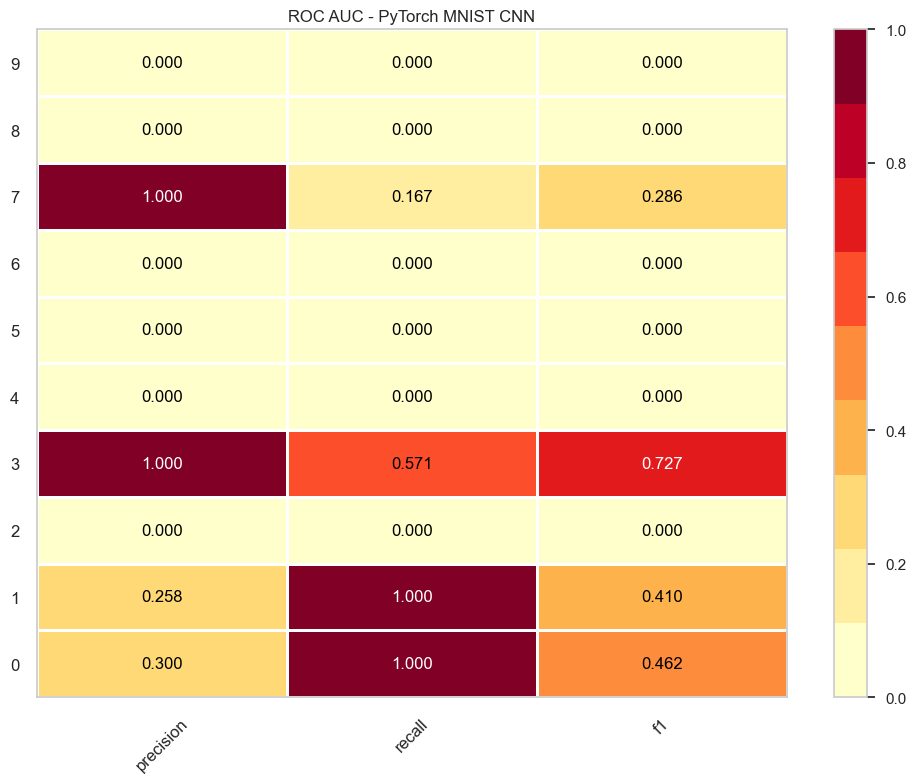

In [11]:
from typing import get_args

from deckard.plugins.yellowbrick.plot import YellowbrickPlotConfig, YellowBrickVizType

yb_path = (PLOT_DIR / "pytorch_roc_auc.png").as_posix()

yb_plot = YellowbrickPlotConfig(
    experiment=experiment,
    plot_type="classification_report",
    features="all",
    classes="all",
    title="ROC AUC - PyTorch MNIST CNN",
    save_path=yb_path,
)

yb_plot()
print("Yellowbrick plot written:", yb_path)
print("Other plots:", get_args(YellowBrickVizType))

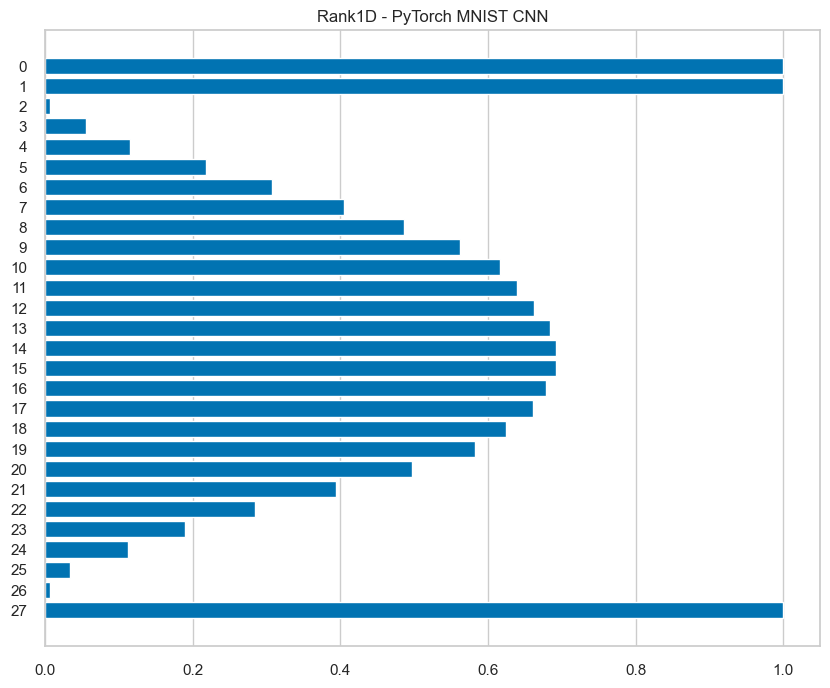

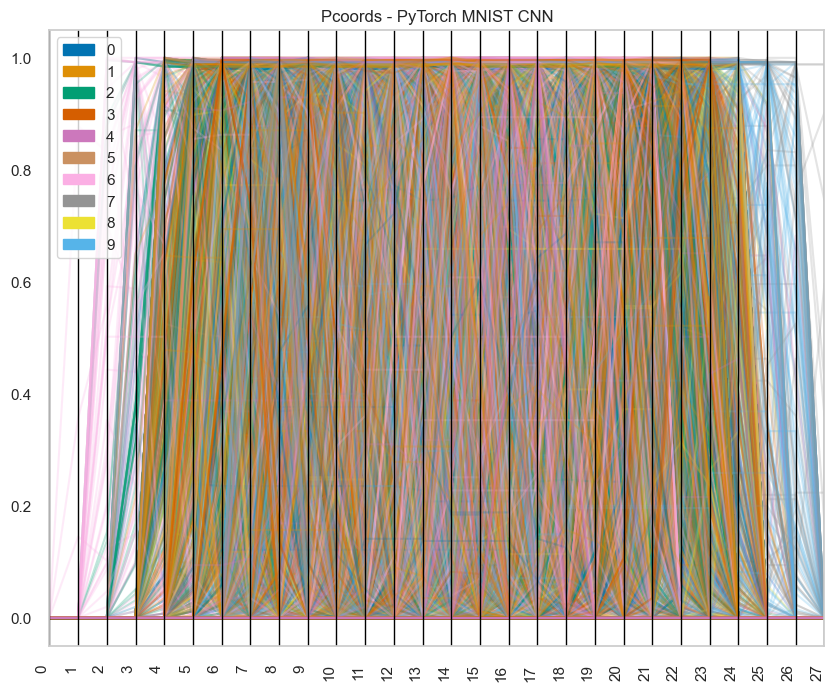

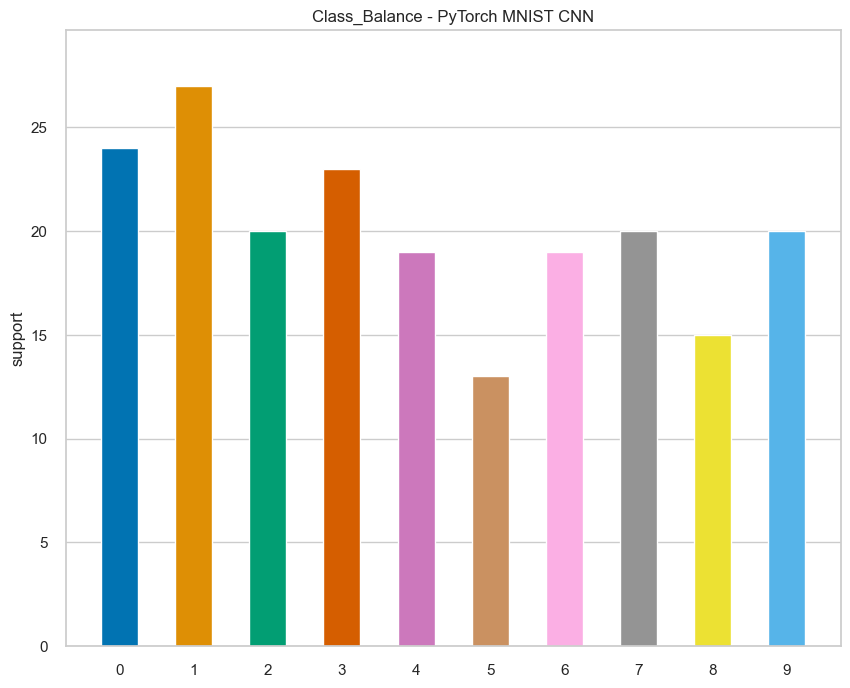

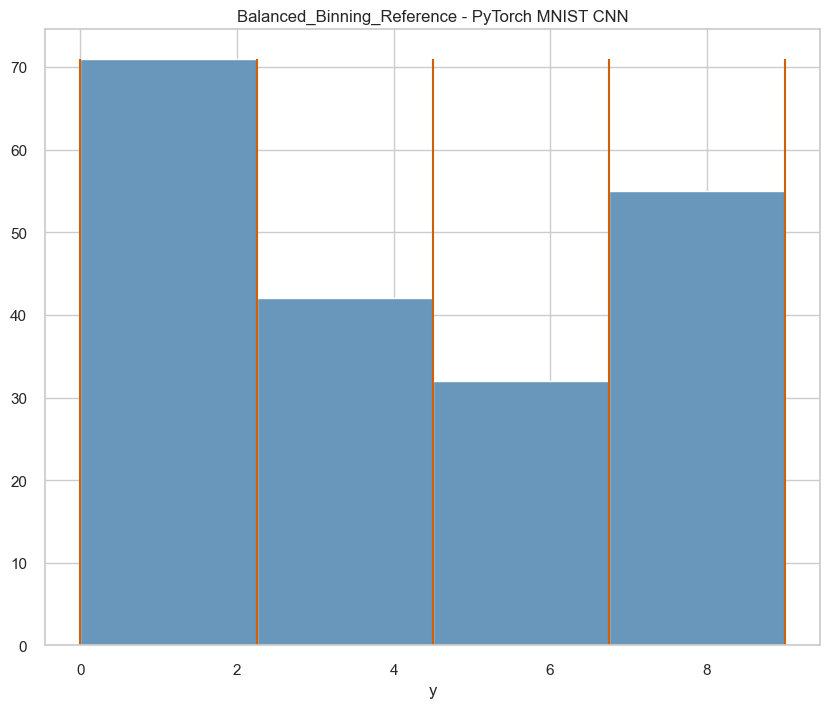

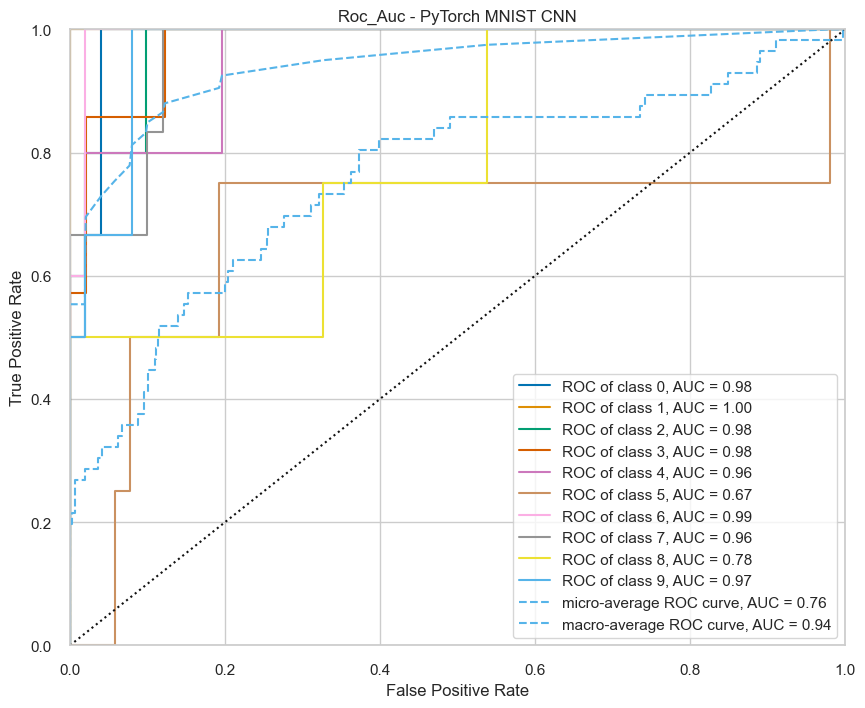

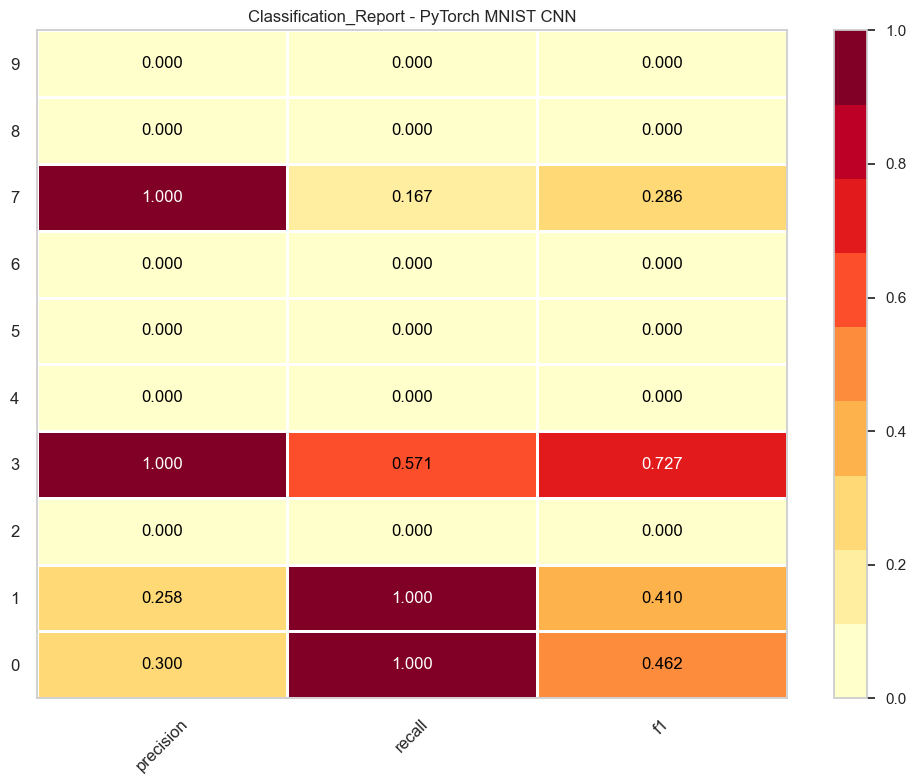

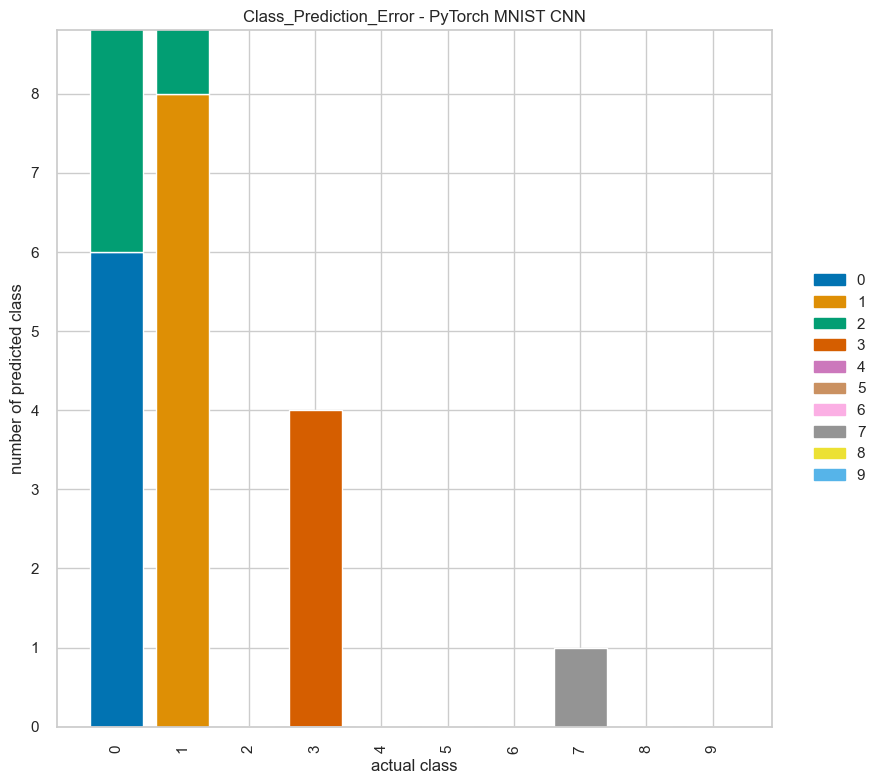

In [12]:
plots = []
status = []
for plot_type in get_args(YellowBrickVizType):
    yb_plot = YellowbrickPlotConfig(
        experiment=experiment,
        plot_type=plot_type,
        features="all",
        classes="all",
        title=f"{plot_type.title()} - PyTorch MNIST CNN",
    )
    plots.append(plot_type)
    try:
        yb_plot()
        status.append("Implemented")
    except:
        plt.close()
        status.append("Not Implemented")

In [13]:
status_ser = pd.Series(status)
plots_ser = pd.Series(plots)
df = pd.DataFrame(status_ser, columns=["Status"])
df["Plot Type"] = plots_ser
df[df["Status"] == "Implemented"]

,Status,Plot Type
0,Implemented,rank1d
3,Implemented,pcoords
7,Implemented,class_balance
8,Implemented,balanced_binning_reference
13,Implemented,roc_auc
15,Implemented,classification_report
16,Implemented,class_prediction_error


## 10. Seaborn Plotter

The Seaborn backend aggregates tabular result CSVs into publication-ready plots. This example builds a small in-memory results table, writes it to disk, and renders a scatter + line plot pair using `SeabornPlotConfigList`.

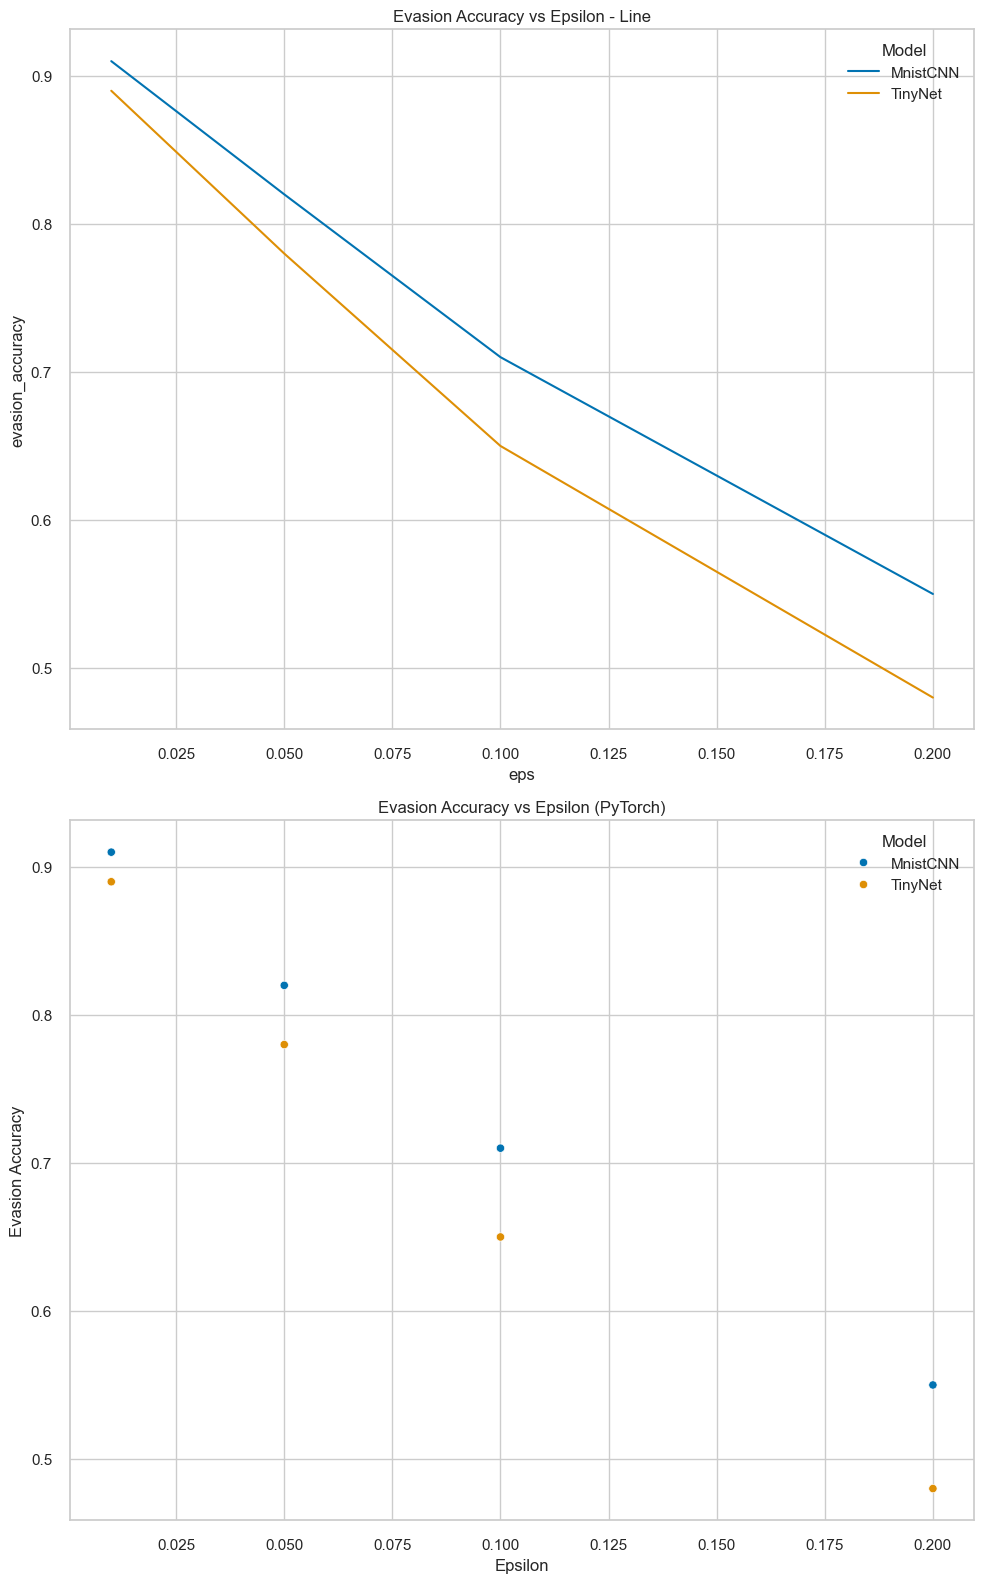

Seaborn plots written: build/pytorch/plots/pytorch_scatter.png build/pytorch/plots/pytorch_line.png


In [14]:
results_df = pd.DataFrame(
    {
        "eps": [0.01, 0.05, 0.10, 0.20, 0.01, 0.05, 0.10, 0.20],
        "evasion_accuracy": [0.91, 0.82, 0.71, 0.55, 0.89, 0.78, 0.65, 0.48],
        "accuracy": [0.94, 0.94, 0.94, 0.94, 0.91, 0.91, 0.91, 0.91],
        "model": ["MnistCNN"] * 4 + ["TinyNet"] * 4,
    }
)

results_csv = ARTIFACT_DIR / "pytorch_results.csv"
results_df.to_csv(results_csv, index=False)

scatter_path = (PLOT_DIR / "pytorch_scatter.png").as_posix()
line_path = (PLOT_DIR / "pytorch_line.png").as_posix()

seaborn_scatter = SeabornPlotConfig(
    plot_type="scatter",
    data_file=results_csv.as_posix(),
    x="eps",
    y="evasion_accuracy",
    hue="model",
    title="Evasion Accuracy vs Epsilon (PyTorch)",
    xlabel="Epsilon",
    ylabel="Evasion Accuracy",
    legend_title="Model",
    plot_file=scatter_path,
)

plot_list = SeabornPlotConfigList(
    data_file=results_csv.as_posix(),
    plots=[
        SeabornPlotConfig(
            plot_type="line",
            data_file=results_csv.as_posix(),
            x="eps",
            y="evasion_accuracy",
            hue="model",
            title="Evasion Accuracy vs Epsilon - Line",
            plot_file=line_path,
            legend_title="Model",
        ),
        seaborn_scatter,
    ],
)
axes = plot_list()
plt.show()
print("Seaborn plots written:", scatter_path, line_path)